## Week 8 — GP Matérn-5/2 + qLogNEI + Interior Penalty (4D)

This notebook fits a GP surrogate on cumulative Week 8 data and proposes the next sample using
**qLogNoisyExpectedImprovement** with distance-based selection and **multiplicative interior penalty**.

**Strategy:**
- `log1p` → z-score output transform for positive, heavy-tailed outputs
- 15-restart MLL fitting to avoid local optima
- q=4 batch NEI → distance-based selection (mean ≥ median, farthest from data)
- Interior penalty suppresses boundary-hugging proposals

In [1]:
import numpy as np
import torch
import copy
import warnings
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)

### Hyperparameter Documentation

| # | Hyperparameter | Value | Justification |
|---|---------------|-------|---------------|
| 1 | Kernel ν | 2.5 | Matérn-5/2 with ARD |
| 2 | ARD dims | 4 | Per-dimension lengthscale |
| 3 | Noise floor | 1e-6 | Prevents collapse |
| 4 | Output transform | log1p → z-score | Heavy-tailed positive outputs |
| 5 | outcome_transform | None | Explicitly disable default Standardize |
| 6 | MLL restarts | 15 | Avoids local optima |
| 7 | Lengthscale init | 0.5 | Exploration-promoting |
| 8 | Noise init | 0.1 × var(Y) | Conservative |
| 9 | Outputscale init | 1.0 | Standard |
| 10 | Acquisition | qLogNEI | Log-space NEI |
| 11 | MC samples | 512 | SobolQMCNormalSampler |
| 12 | q | 4 | Batch candidates |
| 13 | Acq restarts | 50 | Thorough search |
| 14 | Raw samples | 3000 | Large init pool |
| 15 | Selection | Distance-based | Mean ≥ median, farthest from data |
| 16 | IP STEEPNESS | 1.0 | Boundary suppression |
| 17 | IP FLOOR | 0.01 | Minimum penalty at boundary |

In [2]:
# ── Constants ──
N_RESTARTS = 15
STEEPNESS = 1.0
FLOOR = 0.01
DIM = 4

### Step 1: Load Week 8 Data

In [3]:
# Load Week 8 cumulative data
X_raw = np.load('../../data/f5/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f5/updated_outputs - Week 8.npy')

assert X_raw.shape == (28, 4), f"Expected (28, 4), got {X_raw.shape}"
assert y_raw.shape == (28,), f"Expected (28,), got {y_raw.shape}"
assert X_raw.min() >= 0.0 and X_raw.max() <= 1.0, "Inputs out of [0, 1]"

best_idx = int(y_raw.argmax())
print(f"Week 8 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Input range:  [{X_raw.min():.6f}, {X_raw.max():.6f}]")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed value: {y_raw[best_idx]:.6f} at index #{best_idx}")
print(f"Best observed point: {X_raw[best_idx]}")

# Per-dimension ranges
for d in range(DIM):
    print(f"  x{d}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

Week 8 Data: 28 samples, 4 dimensions
Input range:  [0.000000, 1.000000]
Output range: [0.112940, 3394.679933]
Best observed value: 3394.679933 at index #26
Best observed point: [0.989923 0.278871 0.923543 0.995886]
  x0: [0.000000, 0.989923]
  x1: [0.000000, 0.862540]
  x2: [0.088947, 1.000000]
  x3: [0.010000, 1.000000]


### Step 2: GP Surrogate — 15-Restart MLL with log1p → z-score

In [4]:
# Transform: log1p → z-score
y_log = np.log1p(y_raw)
y_mean = y_log.mean()
y_std_val = y_log.std()
y_std = (y_log - y_mean) / y_std_val
print(f"Transform stats: y_log mean={y_mean:.6f}, std={y_std_val:.6f}")
print(f"Standardised: mean={y_std.mean():.6f}, std={y_std.std():.6f}")

# Convert to torch tensors
X_train = torch.tensor(X_raw, dtype=torch.double)
Y_train = torch.tensor(y_std, dtype=torch.double).unsqueeze(-1)

# 15-restart MLL fitting
best_loss = float('inf')
best_model = None

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)
    
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-6))
    covar = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood,
                         outcome_transform=None)
    
    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.1 * Y_train.var().item()
    model.covar_module.outputscale = 1.0
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
    except Exception as e:
        print(f"{seed:>8d} {'FAILED':>12}")
        continue
    
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, Y_train.squeeze(-1)).item()
    
    print(f"{seed:>8d} {loss:>12.4f}")
    
    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

assert best_model is not None, "All restarts failed!"

# Report fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
os_val = best_model.covar_module.outputscale.detach().cpu().item()
noise = best_model.likelihood.noise.detach().cpu().item()

print(f"\n{'='*50}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters:")
for i, l in enumerate(ls):
    print(f"  ℓ_{i+1} (x{i}) = {l:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")

Transform stats: y_log mean=4.935406, std=2.051071
Standardised: mean=0.000000, std=1.000000

 Restart      Neg MLL
----------------------
       0      -5.6419
       1      -5.6419
       2      -5.6419
       3      -5.6419
       4      -5.6419
       5      -5.6419
       6      -5.6419
       7      -5.6419
       8      -5.6419
       9      -5.6419
      10      -5.6419
      11      -5.6419
      12      -5.6419
      13      -5.6419
      14      -5.6419

Best restart neg MLL: -5.641881
Fitted Hyperparameters:
  ℓ_1 (x0) = 2.086596
  ℓ_2 (x1) = 0.656846
  ℓ_3 (x2) = 1.002689
  ℓ_4 (x3) = 0.654164
  σ²_f (output scale) = 2.864550
  σ²_n (noise)        = 0.000001


### Step 3: qLogNEI Acquisition (q=4) + Distance-Based Selection

In [5]:
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([512]))
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

BOUNDS = torch.tensor([[0.0]*DIM, [1.0]*DIM], dtype=torch.double)

candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=4,
    num_restarts=50,
    raw_samples=3000,
)

# Clamp to [0, 0.999999]
candidates = torch.clamp(candidates, 0.0, 0.999999)

# Evaluate posterior at candidates
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means_std = posterior.mean.squeeze(-1).cpu().numpy()
    # Inverse transform: z-score⁻¹ → expm1
    pred_means_orig = np.expm1(pred_means_std * y_std_val + y_mean)

# Min-distance from each candidate to training data
dists = torch.cdist(candidates, X_train).min(dim=1).values

# Distance-based selection: mean ≥ median, farthest from data
median_mean = np.median(pred_means_orig)
above_median = pred_means_orig >= median_mean

print(f"=== NEI Acquisition Results (Week 8, q=4) ===")
print(f"{'Cand':>5} {'Coords':>45} {'Mean(std)':>10} {'Mean(orig)':>12} {'MinDist':>8} {'Above Med?':>11}")
print("-" * 100)
for i in range(candidates.shape[0]):
    coords = candidates[i].cpu().numpy()
    coord_str = "[" + ", ".join(f"{v:.6f}" for v in coords) + "]"
    flag = "✓" if above_median[i] else " "
    print(f"{i+1:>5} {coord_str:>45} {pred_means_std[i]:>10.6f} {pred_means_orig[i]:>12.2f} {dists[i].item():>8.4f} {flag:>11}")

# Select: among above-median, pick farthest
above_median_indices = np.where(above_median)[0]
above_median_dists = dists[above_median_indices].cpu().numpy()
best_among_filtered = above_median_indices[np.argmax(above_median_dists)]
best_point = candidates[best_among_filtered].cpu().numpy()

print(f"\nMedian posterior mean (orig): {median_mean:.2f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ Selected candidate #{best_among_filtered + 1} (farthest from data among above-median)")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in best_point)}]")
print(f"  Posterior mean (orig): {pred_means_orig[best_among_filtered]:.2f}")
print(f"  Min-distance to data:  {dists[best_among_filtered].item():.4f}")
print(f"  Acquisition value: {acq_value.item():.6f}")

=== NEI Acquisition Results (Week 8, q=4) ===
 Cand                                        Coords  Mean(std)   Mean(orig)  MinDist  Above Med?
----------------------------------------------------------------------------------------------------
    1      [0.999999, 0.000000, 0.000000, 0.999999]   0.695261       578.08   0.6094            
    2      [0.000000, 0.000000, 0.395129, 0.999999]   1.185569      1582.03   0.6049           ✓
    3      [0.999999, 0.999999, 0.999999, 0.999999]   1.294416      1978.00   0.4698           ✓
    4      [0.000000, 0.000000, 0.000000, 0.999999]   1.078255      1269.27   0.7206            

Median posterior mean (orig): 1425.65
Above-median candidates: [np.int64(2), np.int64(3)]

→ Selected candidate #2 (farthest from data among above-median)
  Coordinates: [0.000000, 0.000000, 0.395129, 0.999999]
  Posterior mean (orig): 1582.03
  Min-distance to data:  0.6049
  Acquisition value: -0.949674


### Step 4: Interior Penalty Re-Scoring

**Multiplicative Interior Penalty** on posterior mean:
- $w(\mathbf{x}) = \text{FLOOR} + (1 - \text{FLOOR}) \prod_i \sin(\pi x_i)^{2 \cdot \text{STEEPNESS}}$
- $\text{weighted\_mean} = \mu(\mathbf{x}) \times w(\mathbf{x})$
- Then distance-based selection on weighted means

In [6]:
# Compute interior penalty weight for each candidate
cand_np = candidates.cpu().numpy()
raw_penalty = np.prod(np.sin(np.pi * cand_np) ** (2 * STEEPNESS), axis=1)
interior_weight = FLOOR + (1 - FLOOR) * raw_penalty

# Re-score: penalty-weighted posterior mean
weighted_means = pred_means_orig * interior_weight

# Distance-based selection on penalised means
above_median_ip = weighted_means >= np.median(weighted_means)
above_median_idx_ip = np.where(above_median_ip)[0]
above_median_dists_ip = dists[above_median_idx_ip].cpu().numpy()
best_ip_idx = above_median_idx_ip[np.argmax(above_median_dists_ip)]

next_x_ip = np.clip(cand_np[best_ip_idx], 0.0, 0.999999)
min_dist_ip = np.min(np.linalg.norm(X_raw - next_x_ip, axis=1))

# Diagnostic table
print(f"=== Interior Penalty Re-Scoring (4D, q=4) ===")
print(f"  STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"\n{'#':>3} {'Coordinates':>45} {'RawMean':>10} {'Penalty':>8} {'WtdMean':>10} {'Dist':>8} {'Sel':>4}")
print("-" * 95)
for i in range(cand_np.shape[0]):
    coords = "[" + ", ".join(f"{v:.6f}" for v in cand_np[i]) + "]"
    sel = " ★" if i == best_ip_idx else "  "
    print(f"{i+1:>3} {coords:>45} {pred_means_orig[i]:>10.2f} {interior_weight[i]:>8.4f} {weighted_means[i]:>10.2f} {dists[i].item():>8.4f} {sel:>4}")

print(f"\n→ Selected candidate #{best_ip_idx + 1} (interior-penalised)")
print(f"  Point: [{', '.join(f'{v:.6f}' for v in next_x_ip)}]")
print(f"  Weighted mean: {weighted_means[best_ip_idx]:.2f}")
print(f"  Min distance to data: {min_dist_ip:.4f}")

if min_dist_ip < 0.05:
    print(f"  ⚠ WARNING: min distance {min_dist_ip:.4f} < 0.05 threshold")
else:
    print(f"  ✓ Min distance check passed (≥ 0.05)")

=== Interior Penalty Re-Scoring (4D, q=4) ===
  STEEPNESS=1.0, FLOOR=0.01

  #                                   Coordinates    RawMean  Penalty    WtdMean     Dist  Sel
-----------------------------------------------------------------------------------------------
  1      [0.999999, 0.000000, 0.000000, 0.999999]     578.08   0.0100       5.78   0.6094     
  2      [0.000000, 0.000000, 0.395129, 0.999999]    1582.03   0.0100      15.82   0.6049    ★
  3      [0.999999, 0.999999, 0.999999, 0.999999]    1978.00   0.0100      19.78   0.4698     
  4      [0.000000, 0.000000, 0.000000, 0.999999]    1269.27   0.0100      12.69   0.7206     

→ Selected candidate #2 (interior-penalised)
  Point: [0.000000, 0.000000, 0.395129, 0.999999]
  Weighted mean: 15.82
  Min distance to data: 0.6049
  ✓ Min distance check passed (≥ 0.05)


### Step 5: Surrogate Visualisation (3-Panel) + Dimension Relevance

Top-2 dims: x3, x1 (ℓ=0.6542, 0.6568)
Fixed dims: x2=0.3951, x0=0.0000


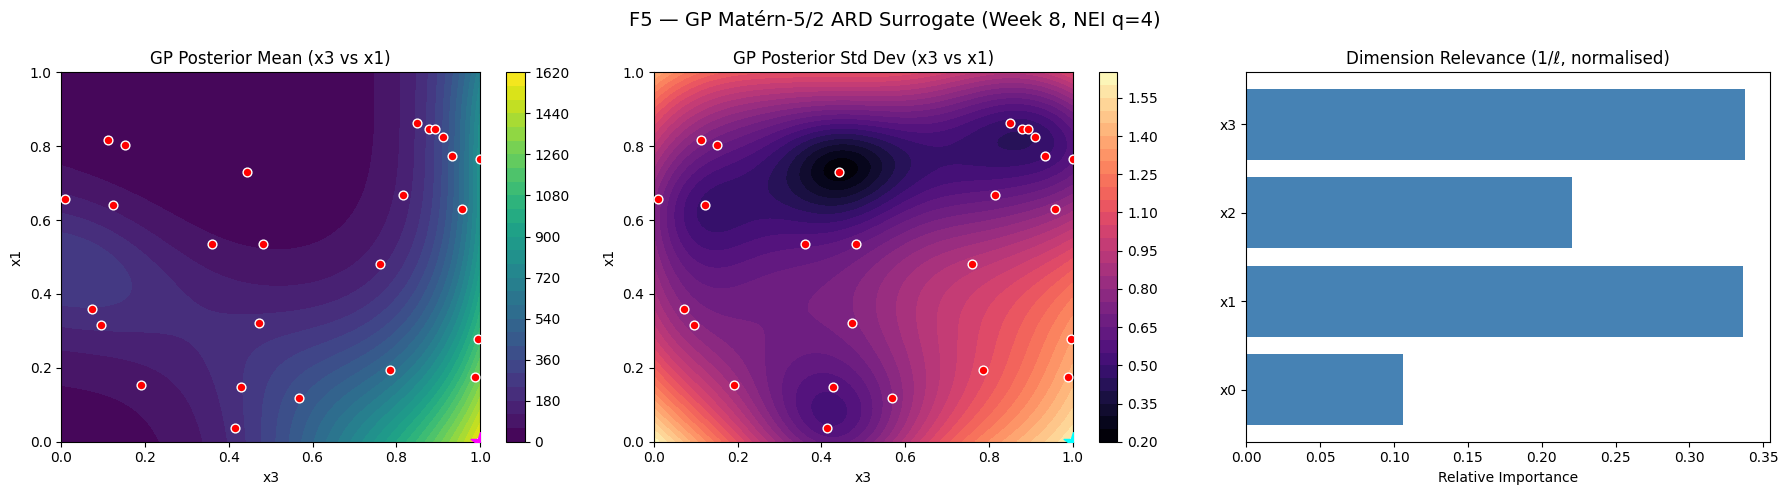

In [7]:
# Identify top-2 important dims (shortest lengthscales)
sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]} (ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d}={best_point[d]:.4f}" for d in fix_dims))

# Build 80×80 grid
grid_res = 80
g0 = np.linspace(0, 1, grid_res)
g1 = np.linspace(0, 1, grid_res)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(best_point, (grid_res * grid_res, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu_std = posterior.mean.squeeze(-1).cpu().numpy()
    grid_sigma_std = posterior.variance.sqrt().squeeze(-1).cpu().numpy()

grid_mu_orig = np.expm1(grid_mu_std * y_std_val + y_mean).reshape(grid_res, grid_res)
grid_sigma_orig = (grid_sigma_std * y_std_val).reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean
c1 = axes[0].contourf(G0, G1, grid_mu_orig, levels=30, cmap="viridis")
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(G0, G1, grid_sigma_orig, levels=30, cmap="magma")
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(DIM), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(DIM))
axes[2].set_yticklabels([f"x{j}" for j in range(DIM)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F5 — GP Matérn-5/2 ARD Surrogate (Week 8, NEI q=4)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Interior Penalty Visualisation (3-Panel)

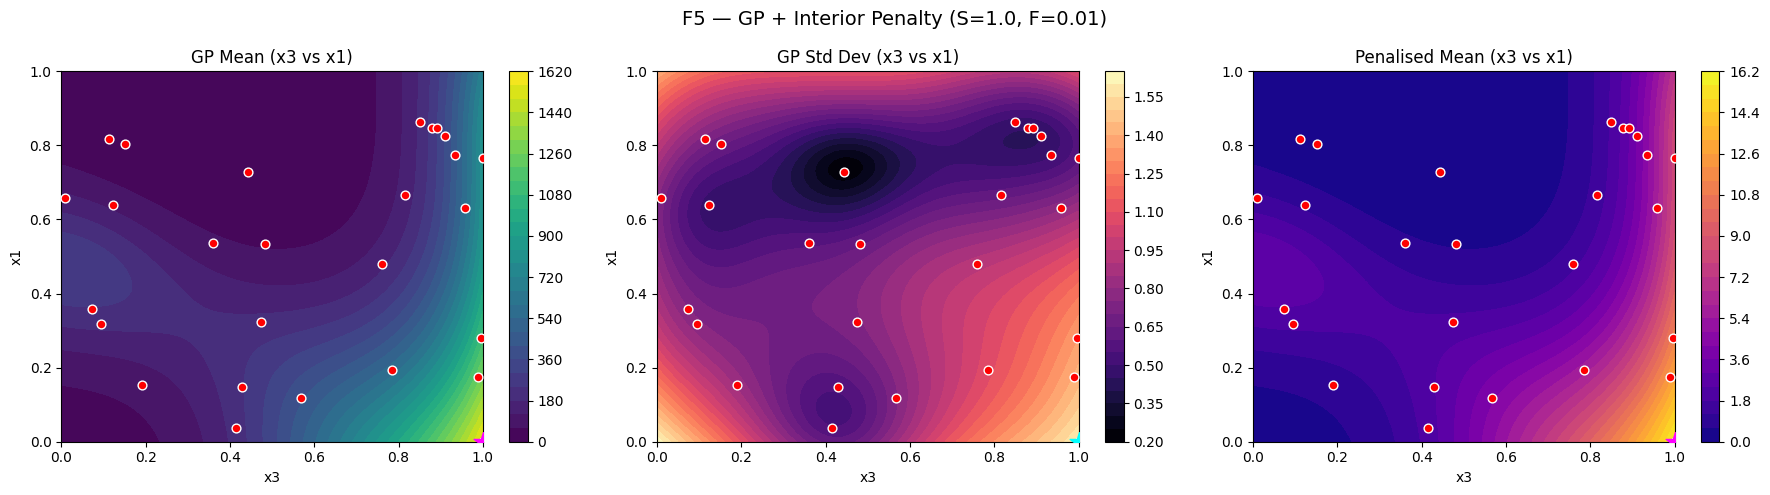

In [8]:
# IP grid using the IP-selected point for fixed dims
grid_pts_ip = np.tile(next_x_ip, (grid_res * grid_res, 1))
grid_pts_ip[:, top2[0]] = G0.ravel()
grid_pts_ip[:, top2[1]] = G1.ravel()

grid_tensor_ip = torch.tensor(grid_pts_ip, dtype=torch.double)
with torch.no_grad():
    posterior_ip = best_model.posterior(grid_tensor_ip)
    grid_mu_std_ip = posterior_ip.mean.squeeze(-1).cpu().numpy()
    grid_sigma_std_ip = posterior_ip.variance.sqrt().squeeze(-1).cpu().numpy()

grid_mu_orig_ip = np.expm1(grid_mu_std_ip * y_std_val + y_mean).reshape(grid_res, grid_res)
grid_sigma_orig_ip = (grid_sigma_std_ip * y_std_val).reshape(grid_res, grid_res)

# Interior penalty on grid
grid_penalty_ip = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * grid_pts_ip) ** (2 * STEEPNESS), axis=1
).reshape(grid_res, grid_res)
grid_penalised_mean_ip = grid_mu_orig_ip * grid_penalty_ip

fig_ip, axes_ip = plt.subplots(1, 3, figsize=(18, 5))

c1_ip = axes_ip[0].contourf(G0, G1, grid_mu_orig_ip, levels=30, cmap="viridis")
axes_ip[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[0].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes_ip[0].set_title(f"GP Mean (x{top2[0]} vs x{top2[1]})")
axes_ip[0].set_xlabel(f"x{top2[0]}")
axes_ip[0].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c1_ip, ax=axes_ip[0])

c2_ip = axes_ip[1].contourf(G0, G1, grid_sigma_orig_ip, levels=30, cmap="magma")
axes_ip[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[1].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes_ip[1].set_title(f"GP Std Dev (x{top2[0]} vs x{top2[1]})")
axes_ip[1].set_xlabel(f"x{top2[0]}")
axes_ip[1].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c2_ip, ax=axes_ip[1])

c3_ip = axes_ip[2].contourf(G0, G1, grid_penalised_mean_ip, levels=30, cmap="plasma")
axes_ip[2].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[2].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes_ip[2].set_title(f"Penalised Mean (x{top2[0]} vs x{top2[1]})")
axes_ip[2].set_xlabel(f"x{top2[0]}")
axes_ip[2].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c3_ip, ax=axes_ip[2])

plt.suptitle(f"F5 — GP + Interior Penalty (S={STEEPNESS}, F={FLOOR})", fontsize=14)
plt.tight_layout()
plt.show()

### Step 7: Convergence Plot

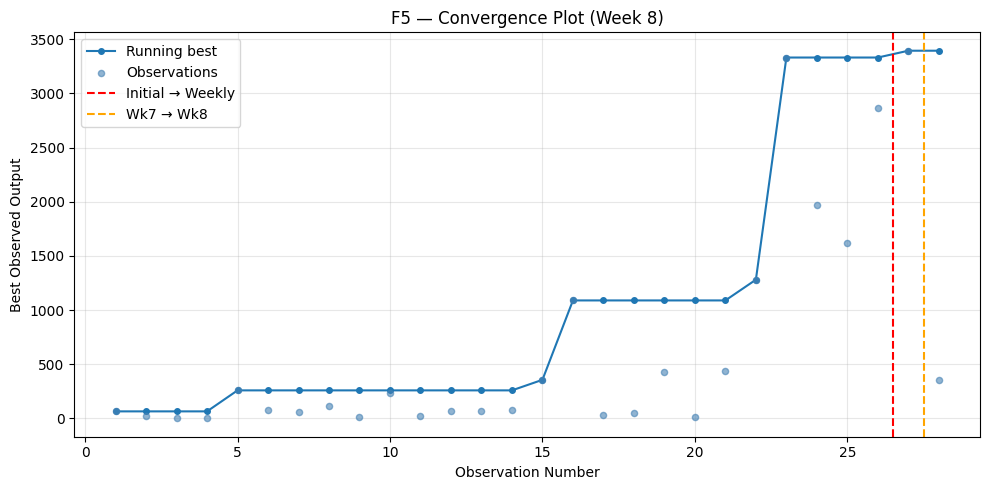

Running best at Week 8 end (sample 28): 3394.679933


In [9]:
# Convergence plot
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, marker="o", markersize=4, linewidth=1.5, label="Running best")
plt.scatter(range(1, len(y_raw) + 1), y_raw, c="steelblue", s=20, alpha=0.6, zorder=3, label="Observations")
plt.axvline(x=26.5, color="red", linestyle="--", label="Initial → Weekly")
plt.axvline(x=27.5, color="orange", linestyle="--", label="Wk7 → Wk8")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F5 — Convergence Plot (Week 8)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 8 end (sample {len(y_raw)}): {running_best[-1]:.6f}")

### Step 8: Submission — Base NEI + Interior Penalty

In [10]:
# ── Base NEI Submission ──
submission_base = np.clip(best_point, 0.0, 0.999999)
query_base = "-".join(f"{v:.6f}" for v in submission_base)

print("=" * 60)
print("F5 WEEK 8 — BASE NEI SUBMISSION")
print("=" * 60)
print(f"\n  {query_base}\n")

# ── Interior Penalty Submission ──
submission_ip = np.clip(next_x_ip, 0.0, 0.999999)
query_ip = "-".join(f"{v:.6f}" for v in submission_ip)

print("=" * 60)
print("F5 WEEK 8 — INTERIOR PENALTY SUBMISSION")
print("=" * 60)
print(f"\n  {query_ip}\n")
print("=" * 60)

# Validation
for label, query in [("Base", query_base), ("IP", query_ip)]:
    parts = query.split("-")
    assert len(parts) == DIM, f"{label}: Expected {DIM} dimensions, got {len(parts)}"
    for p in parts:
        v = float(p)
        assert 0.0 <= v <= 0.999999, f"{label}: Value {v} out of bounds"
    print(f"✓ {label} submission format validated")

print(f"\nSurrogate: GP Matérn-5/2 ARD (outcome_transform=None)")
print(f"Acquisition: qLogNEI (q=4) + distance-based selection")
print(f"Interior Penalty: STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"Lengthscales: [{', '.join(f'{l:.6f}' for l in ls)}]")
print(f"Output scale: {os_val:.6f}, Noise: {noise:.6f}")

F5 WEEK 8 — BASE NEI SUBMISSION

  0.000000-0.000000-0.395129-0.999999

F5 WEEK 8 — INTERIOR PENALTY SUBMISSION

  0.000000-0.000000-0.395129-0.999999

✓ Base submission format validated
✓ IP submission format validated

Surrogate: GP Matérn-5/2 ARD (outcome_transform=None)
Acquisition: qLogNEI (q=4) + distance-based selection
Interior Penalty: STEEPNESS=1.0, FLOOR=0.01
Lengthscales: [2.086596, 0.656846, 1.002689, 0.654164]
Output scale: 2.864550, Noise: 0.000001
